<a href="https://colab.research.google.com/github/nidhita2/Deep-Learning/blob/ANN/exp_4_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
#Loading Dataset
df = pd.read_csv('Friday.csv')
df.head()
print(df.shape)
df.info()
print(df.describe)

(225745, 79)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       2

In [3]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
print(df.shape)

(225711, 79)


In [4]:
x = df.drop(columns=[' Label'])
y = df[' Label']
print(x.head())
print(y.value_counts())

    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                             6                 

In [5]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(label_encoder.classes_)

['BENIGN' 'DDoS']


In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(180568, 78)
(45143, 78)
(180568,)
(45143,)


In [7]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
print(x_train)
print(x_test)

[[-0.4451106  -0.51086992 -0.12056838 ... -0.28352491 -0.47888119
  -0.39138596]
 [-0.4451106  -0.19423396  0.07214295 ... -0.28352491 -0.10396056
   0.11766207]
 [-0.44647818 -0.51571054 -0.18480549 ... -0.28352491 -0.47888119
  -0.39138596]
 ...
 [-0.44647818 -0.51381607 -0.2490426  ... -0.28352491 -0.47888119
  -0.39138596]
 [-0.4451106  -0.50267171 -0.12056838 ... -0.28352491 -0.47888119
  -0.39138596]
 [-0.44647818 -0.5136807  -0.18480549 ... -0.28352491 -0.47888119
  -0.39138596]]
[[-0.4451106   1.79516493  0.20061717 ...  3.12268046  2.01564022
  -0.10788844]
 [-0.4451106   2.02863987  0.20061717 ...  3.57684118  2.3014708
  -0.12703152]
 [ 2.86282059  2.06493388  0.00790584 ... -0.28352491  2.50934758
   3.66587797]
 ...
 [-0.4451106  -0.31142445 -0.05633127 ... -0.28352491 -0.23990277
  -0.0669133 ]
 [-0.44647818 -0.50879008 -0.2490426  ... -0.28352491 -0.47888119
  -0.39138596]
 [-0.4451106  -0.48631816 -0.12056838 ... -0.28352491 -0.47888119
  -0.39138596]]


In [9]:
# Building ANN
ann = Sequential()

#Input layer + Hidden layer
ann.add(Dense(units = 64, activation = 'relu'))#Unit represents the no. of perceptron (input)
ann.add(Dropout(0.2))
ann.add(Dense(units = 32, activation = 'relu'))#Hidden Layer
ann.add(Dropout(0.2))

#Output layer
ann.add(Dense(units = 1, activation = 'sigmoid'))#Output Layer

In [10]:
# Compile Model
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)
ann.compile(optimizer = optimizer, loss = 'binary_crossentropy', metrics = ['accuracy'])

In [11]:
# Early Stopping Function
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [14]:
# Train
history = ann.fit(x_train, y_train, batch_size = 64, epochs = 10, validation_split = 0.20, callbacks=[early_stopping])

Epoch 1/10
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9996 - val_loss: 0.0017
Epoch 2/10
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9996 - val_loss: 0.0016
Epoch 3/10
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 0.9996 - val_loss: 0.0020
Epoch 4/10
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9996 - val_loss: 0.0016
Epoch 5/10
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9997 - val_loss: 0.0013
Epoch 6/10
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9998 - val_loss: 0.0013
Epoch 7/10
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9996 - loss: 0.0017 - val_accuracy: 0.9995 - val_loss: 0.0018
Epoch 8/10
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9995 - loss: 0.0016 - 

In [15]:
#Prediction
y_pred = ann.predict(x_test)
y_pred = (y_pred > 0.5)
print(y_pred[0:10])

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
[[ True]
 [ True]
 [False]
 [False]
 [ True]
 [ True]
 [False]
 [False]
 [ True]
 [ True]]


In [16]:
#Model Evaluation
ac = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Accuracy Score : ", ac)
print("Confusion Matrix : ")
print(cm)
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy Score :  0.9997120262277651
Confusion Matrix : 
[[19530     8]
 [    5 25600]]
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



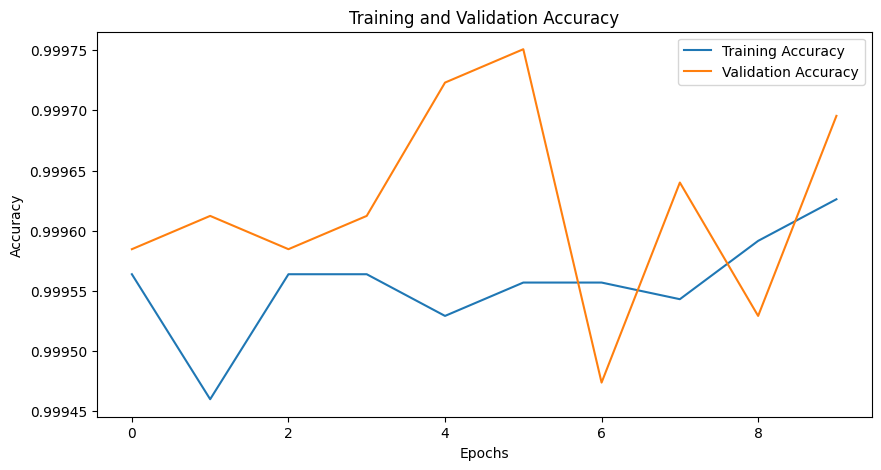

In [17]:
#Accuracy Graph
plt.figure(figsize = (10,5))
plt.plot(history.history['accuracy'], label = "Training Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

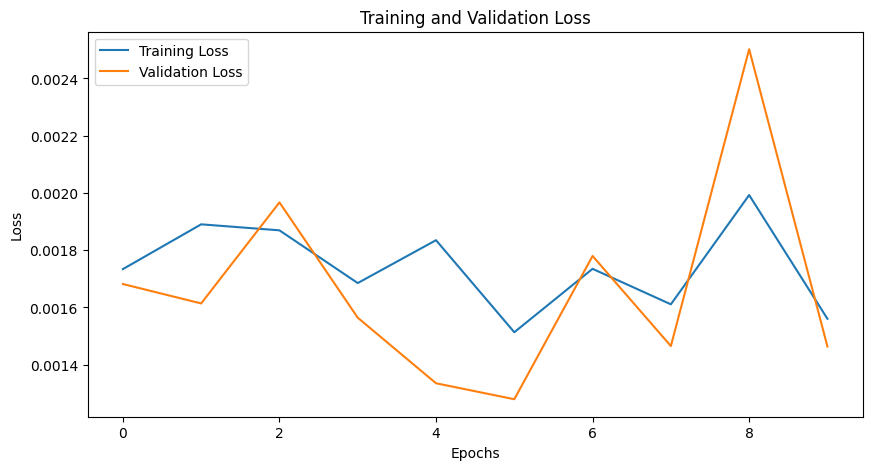

In [18]:
# Loss Graph
plt.figure(figsize = (10,5))
plt.plot(history.history['loss'], label = "Training Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()